<a href="https://colab.research.google.com/github/Code845-cp/ACM-Recruitment--Shreya-S-Nair-/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

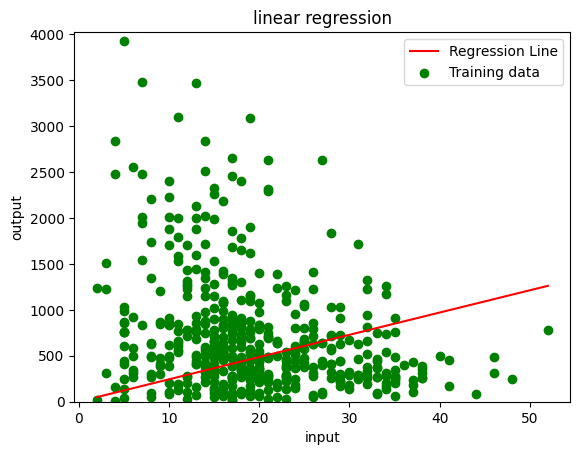

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
!apt-get update
!apt-get install ffmpeg -y
df=pd.read_csv('/content/sample_data/california_housing_train.csv')
df=df.dropna()
train_input = np.array(df['housing_median_age'][0:500]).reshape(-1,1)
train_output=np.array(df['total_bedrooms'][0:500])
test_input = np.array(df['housing_median_age'][500:700]).reshape(-1,1)
test_output = np.array(df['total_bedrooms'][500:700])
class LinearRegression:
  def __init__(self):
    self.parameters={}
  def forward_propagation(self,train_input):
    m=self.parameters['m']
    c=self.parameters['c']
    predictions=np.multiply(m,train_input)+c
    return predictions
  def cost_function(self,predictions,train_output):
    cost=np.mean((train_output-predictions)**2)
    return cost
  def backward_propagation(self,train_input,train_output,predictions):
    derivatives={}
    df=(predictions.flatten()-train_output)
    dm=2*np.mean(np.multiply(df,train_input.flatten()))
    dc=2*np.mean(df)
    derivatives['dm']=dm
    derivatives['dc']=dc
    return derivatives
  def update_parameters(self,derivatives,learning_rate):
    self.parameters['m']=self.parameters['m']-learning_rate*derivatives['dm']
    self.parameters['c']=self.parameters['c']-learning_rate*derivatives['dc']
  def train(self,train_input,train_output,learning_rate,iters):
    self.parameters['m']=np.random.uniform(0,1)*-1
    self.parameters['c']=np.random.uniform(0,1)*-1
    self.loss=[]
    fig,ax=plt.subplots()
    x_vals=np.linspace(min(train_input),max(train_input),100)
    line,=ax.plot(x_vals,self.parameters['m']*x_vals+self.parameters['c'],color='red',label='Regression Line' )
    ax.scatter(train_input,train_output,marker='o',color='green',label='Training data')
    ax.set_ylim(0,max(train_output)+100)
    def update(frame):
      predictions=self.forward_propagation(train_input)
      cost=self.cost_function(predictions,train_output)
      derivatives=self.backward_propagation(train_input,train_output,predictions)
      self.update_parameters(derivatives,learning_rate)
      line.set_ydata(self.parameters['m']*x_vals+self.parameters['c'])
      self.loss.append(cost)
      print("Iteration={},loss={}".format(frame+1,cost))
      return line,
    ani=FuncAnimation(fig, update,frames=iters,interval=200,blit=True)
    ani.save('linear_regression_A.gif',writer='ffmpeg')
    plt.xlabel('input')
    plt.ylabel('output')
    plt.title('linear regression')
    plt.legend()
    plt.show()
    return self.parameters,self.loss
linear_reg = LinearRegression()
parameters, loss = linear_reg.train(train_input, train_output, 0.0001, 20)

